In [1]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

from pyfrechet.metric_spaces import MetricData, Euclidean, two_euclidean
from pyfrechet.regression.bagged_regressor import BaggedRegressor
from sklearn.preprocessing import MinMaxScaler
import multiprocessing as mp

import sys
import time

INFO: Using numpy backend


In [2]:
# Function to simulate multivariate regression data
def two_simulate_data(sigma, X_design):
    sample_size = X_design.shape[0]

    # Generate the error term epsilon, which follows a multivariate normal distribution
    epsilon = np.random.normal(0, sigma, size = sample_size).reshape(sample_size, 1)
    
    # Step 2: Apply the model transformations
    X_1 = X_design  # X_1 corresponds to the first column (without intercept)

    # Calculate the response vector Y = beta_0 + beta_1*X_1 + beta_2*sin(pi*X_2) + beta_3*X_3^2 + beta_4*X_2*X_4 + beta_5*X_5 + epsilon

    Ys = X_1 + epsilon
            
    # Convert list to array for easier manipulation
    Ys = np.array(Ys).reshape(sample_size, 1)
    
    # Center the predictors
    #X_design -= X_design.mean(axis=0)
    
    # Center the responses
    #Ys -= Ys.mean(axis=0)
    
    return X_design, Ys

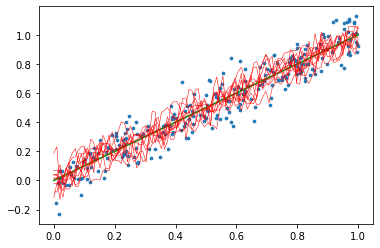

In [3]:
from sklearn.ensemble import RandomForestRegressor
from pyfrechet.regression.trees import Tree
# Create the random forest
M = two_euclidean(dim = 1)
# base = Tree(split_type = '2means', mtry = None, impurity_method = 'cart', min_split_size=1)
# forest = BaggedRegressor(base, n_estimators = 100, bootstrap_fraction=1, bootstrap_replace=True, n_jobs = 1)

forest = RandomForestRegressor(n_estimators = 100, n_jobs=1)
plt.figure()
X_test = np.random.uniform(0, 1, size=(250, 1))
plt.scatter(X_test, two_simulate_data(sigma=0.1, X_design=X_test)[1], label='True values', s=7)
plt.plot(np.linspace(0, 1, 10).reshape(10,1), np.linspace(0, 1, 10).reshape(10,1), color = 'green')
for _ in range(10):
    X_train = np.random.uniform(size=(100, 1))

    # y_train = two_simulate_data(sigma=0.1, X_design=X_train, betas=betas)[1].reshape(-1,1)
    y_train = two_simulate_data(sigma=0.1, X_design=X_train)[1].ravel()

    # forest.fit(X_train, MetricData(M, y_train))
    
    forest.fit(X_train, y_train)
    # oob_quantile = np.percentile(forest.oob_prediction_, (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')

    X_test = np.random.uniform(0, 1, size=(250, 1))
    pred = forest.predict(np.linspace(0, 1, 100).reshape(-1, 1))
    _, y_test = two_simulate_data(sigma=0.1, X_design=X_test)

    plt.plot(np.linspace(0, 1, 100).reshape(100,1), pred, label='Predicted values', color = 'red', linewidth = 0.5)

plt.show()

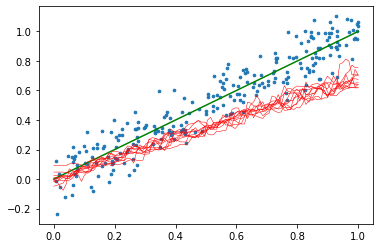

In [4]:
from sklearn.ensemble import RandomForestRegressor
from pyfrechet.regression.trees import Tree
# Create the random forest
M = Euclidean(dim = 1)
plt.figure()
plt.scatter(X_test, y_test, label='True values', s=7)
plt.plot(np.linspace(0, 1, 10).reshape(10,1), np.linspace(0, 1, 10).reshape(10,1), color = 'green')
base = Tree(split_type = '2means', mtry = None, impurity_method = 'cart', min_split_size=1, honesty_fraction=.1)
forest = BaggedRegressor(base, n_estimators = 100, bootstrap_fraction=1, bootstrap_replace=True, n_jobs = 1)

for _ in range(10):
    # forest = RandomForestRegressor(n_estimators = 100, n_jobs=1)
    X_train = np.random.uniform(size=(100, 1))

    y_train = two_simulate_data(sigma=0.1, X_design=X_train)[1]
    # y_train = two_simulate_data(sigma=0.1, X_design=X_train, betas=betas)[1].ravel()

    forest.fit(X_train, MetricData(M, y_train))
    
    # forest.fit(X_train, y_train)

    # oob_quantile = np.percentile(forest.oob_prediction_, (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')

    X_test = np.random.uniform(0, 1, size=(250, 1))
    pred = forest.predict(np.linspace(0, 1, 100).reshape(-1, 1))
    _, y_test = two_simulate_data(sigma=0.1, X_design=X_test)


    plt.plot(np.linspace(0, 1, 100).reshape(100,1), pred, label='Predicted values', color = 'red', linewidth = 0.5)

plt.show()

In [302]:
# Function to simulate multivariate regression data
def simulate_data(dim, sigma, X_design, betas):
    Ys = []
    sample_size = X_design.shape[0]

    # Generate the error term epsilon, which follows a multivariate normal distribution
    epsilon = np.random.multivariate_normal(np.repeat(0, dim), sigma * np.eye(dim), sample_size)
    
    # Step 2: Apply the model transformations
    X_1 = X_design[:, 0, :].reshape(sample_size, dim)  # X_1 corresponds to the first column (without intercept)
    X_2 = X_design[:, 1, :].reshape(sample_size, dim)  # X_2 corresponds to the second column
    X_3 = X_design[:, 2, :].reshape(sample_size, dim)  # X_3 corresponds to the third column

    sin_X2 = np.sin(np.pi * X_2)  # Apply sin to X_2. Note: sine acts element-wise on the array

    Ys = np.repeat(betas[0], sample_size*dim).reshape(sample_size, dim) + betas[1] * X_1 + betas[2] * sin_X2 + betas[3] * X_3 + epsilon
    # Convert list to array for easier manipulation
    Ys = np.array(Ys).reshape(sample_size, dim)
    
    return X_design, Ys

sigma = 0.1
sample_size = 1000
n_predictors = 3
dim = 5
X_design = np.random.uniform(0, 1, (sample_size, n_predictors, dim))

betas = [2, 1, 2, 3]
X, y = simulate_data( dim = dim, sigma=0.1, X_design=X_design, betas=betas)



In [361]:
# Function to simulate regression data
def simulate_data(sigma, X_design, betas, dim):
    Ys = []
    sample_size = X_design.shape[0]

    # Generate the error term epsilon, which follows a normal distribution
    epsilon = np.random.normal(0, sigma, size = sample_size).reshape(sample_size, 1)
    # Step 2: Apply the model transformations
    X_1 = X_design[:, 0]  # X_1 corresponds to the first column (without intercept)
    X_2 = X_design[:, 1]  # X_2 corresponds to the second column
    X_3 = X_design[:, 2]  # X_3 corresponds to the third column

    # Calculate the response vector Y = beta_0 + beta_1*X_1 + beta_2*sin(pi*X_2) + beta_3*X_3^2 + beta_4*X_2*X_4 + beta_5*X_5 + epsilon
    sin_X2 = np.sin(np.pi * X_2)  # Apply sin to X_2

    X = np.hstack((np.ones(sample_size).reshape(sample_size,1), np.stack((X_1, sin_X2, X_3)).T))
    print(dim)
    Ys = X @ betas[:dim, :].T
    print(Ys.shape)
    # Convert list to array for easier manipulation
    Ys = np.array(Ys).reshape(sample_size, dim)    
    return X_design, Ys

X_design = np.random.uniform(0, 1, (sample_size, n_predictors))
betas = np.random.uniform(-2, 2, size = 10*4).reshape(10, 4)  # Define the true beta values
dims = [1, 5, 10]  # Different dimensions for the response vector

x, y = simulate_data(sigma = 0.1, X_design = X_design, betas = betas, dim = 5)

5
(1000, 5)


In [344]:
X_1 = X_design[:, 0]  # X_1 corresponds to the first column (without intercept)
X_2 = X_design[:, 1]  # X_2 corresponds to the second column
X_3 = X_design[:, 2]  # X_3 corresponds to the third column

# Calculate the response vector Y = beta_0 + beta_1*X_1 + beta_2*sin(pi*X_2) + beta_3*X_3^2 + beta_4*X_2*X_4 + beta_5*X_5 + epsilon
sin_X2 = np.sin(np.pi * X_2)  # Apply sin to X_2

combined_array = np.hstack((np.ones(sample_size).reshape(1000,1), np.stack((X_1, sin_X2, X_3)).T))

In [17]:
#y_train = two_simulate_data(sigma=0.1, X_design=X_train)[1].reshape(-1,1)

M_two = two_euclidean(dim = 1)
M = Euclidean(dim = 1)
y_tr_two = MetricData(M_two, y_train)
y_tr = MetricData(M, y_train)
print(M.d(y_tr.data, y_tr.data))
M_two.d(y_tr_two.data, y_tr_two.data)

0.0


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [21]:
from pyfrechet.metric_spaces import MetricData, CustomAffineInvariant
M_af = CustomAffineInvariant(dim = 1)
# Function to simulate SPD matrices
def simulate_spd_matrices(n, dim):
    matrices = []
    for _ in range(n):
        A = np.random.rand(dim, dim)
        spd_matrix = np.dot(A, A.T)  # Create a symmetric positive definite matrix
        matrices.append(spd_matrix)
    return np.array(matrices)

# Simulate 10 SPD matrices of size 2x2
spd_matrices = simulate_spd_matrices(10, 2)
y_spd = MetricData(M_af, spd_matrices)
print(M_af.d(y_spd, y_spd))

[2.22044605e-16 0.00000000e+00 1.86517468e-14 0.00000000e+00
 2.22044605e-16 0.00000000e+00 9.99200722e-16 0.00000000e+00
 2.22044605e-16 0.00000000e+00]


In [10]:
spd_matrices.shape

(10, 2, 2)

In [22]:
# Function to simulate regression data
def simulate_data(sigma, X_design, betas):
    Ys = []
    sample_size = X_design.shape[0]

    # Generate the error term epsilon, which follows a normal distribution
    epsilon = np.random.normal(0, sigma, size = sample_size).reshape(sample_size, 1)
    # X_design = X_design - np.mean(X_design, axis=0)

    # Step 2: Apply the model transformations
    X_1 = X_design[:, 0]  # X_1 corresponds to the first column (without intercept)
    X_2 = X_design[:, 1]  # X_2 corresponds to the second column
    X_3 = X_design[:, 2]  # X_3 corresponds to the third column

    # Calculate the response vector Y = beta_0 + beta_1*X_1 + beta_2*X_2 + beta_3*X_3 + epsilon
    Ys = betas[0] + betas[1] * X_1 + betas[2] * X_2 + betas[3] * X_3
    # Convert list to array for easier manipulation
    Ys = Ys.reshape(sample_size, 1) + epsilon
    
    return X_design, Ys

In [26]:
from sklearn.ensemble import RandomForestRegressor
from pyfrechet.regression.trees import Tree
# Create the random forest
M = Euclidean(dim = 1)
plt.figure()
base = Tree(split_type = '2means', mtry = None, impurity_method = 'cart', min_split_size=1, honesty_fraction=.1)
forest = BaggedRegressor(base, n_estimators = 100, bootstrap_fraction=1, bootstrap_replace=True, n_jobs = 1)
betas = np.array([-2, 2, -1, 1])  # Define the true beta values

for _ in range(1):
    # forest = RandomForestRegressor(n_estimators = 100, n_jobs=1)
    X_train = np.random.uniform(size=(100, 3))

    y_train = simulate_data(sigma=2/3, X_design=X_train, betas = betas)[1]
    # y_train = two_simulate_data(sigma=0.1, X_design=X_train, betas=betas)[1].ravel()

    forest.fit(X_train, MetricData(M, y_train))
    
    # forest.fit(X_train, y_train)

    # oob_quantile = np.percentile(forest.oob_prediction_, (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')

    X_test = np.random.uniform(0, 1, size=(250, 1))
    pred = forest.predict(np.linspace(0, 1, 100).reshape(-1,1))
    _, y_test = two_simulate_data(sigma=0.1, X_design=X_test)


    plt.plot(np.linspace(0, 1, 100).reshape(100,1), pred, label='Predicted values', color = 'red', linewidth = 0.5)

plt.scatter(X_test, y_test, label='True values', s=7)
plt.plot(np.linspace(0, 1, 10).reshape(10,1), np.linspace(0, 1, 10).reshape(10,1), color = 'green')

plt.show()

IndexError: index 2 is out of bounds for axis 0 with size 1

<Figure size 432x288 with 0 Axes>

In [63]:
from scipy.linalg import toeplitz
rho = 0.75
q = 5
toeplitz(np.c_[np.array([1]).reshape(-1,1), np.repeat(rho, q-1).reshape(1,q-1)])

betas

array([[1.  , 0.75, 0.75, 0.75, 0.75],
       [0.75, 1.  , 0.75, 0.75, 0.75],
       [0.75, 0.75, 1.  , 0.75, 0.75],
       [0.75, 0.75, 0.75, 1.  , 0.75],
       [0.75, 0.75, 0.75, 0.75, 1.  ]])

In [72]:
def beta_calculator(j, k):
    return np.sqrt(j) * np.sin(np.pi * k / (q+1))

n_predictors = 3
for j in range(1, n_predictors+1):
    for k in range(1, q+1):
        print(j, k, beta_calculator(j, k))

        beta_matrix = np.zeros((n_predictors, q))
        for j in range(1, n_predictors+1):
            for k in range(1, q+1):
                beta_matrix[j-1, k-1] = beta_calculator(j, k)
print(beta_matrix)

1 1 0.49999999999999994
3 2 1.4999999999999998
3 3 1.7320508075688772
3 4 1.5
3 5 0.8660254037844385
2 1 0.7071067811865475
3 2 1.4999999999999998
3 3 1.7320508075688772
3 4 1.5
3 5 0.8660254037844385
3 1 0.8660254037844385
3 2 1.4999999999999998
3 3 1.7320508075688772
3 4 1.5
3 5 0.8660254037844385
[[0.5        0.8660254  1.         0.8660254  0.5       ]
 [0.70710678 1.22474487 1.41421356 1.22474487 0.70710678]
 [0.8660254  1.5        1.73205081 1.5        0.8660254 ]]


0.08541807584349795

In [8]:
np.array([1,4]).reshape(-1,1)

array([[1],
       [4]])

In [9]:
np.array([-5,9]).reshape(-1,1)

array([[-5],
       [ 9]])

In [10]:
M.d(MetricData(M,np.array([1,4,-1]).reshape(-1,1)), MetricData(M,np.array([-5,9,-4]).reshape(-1,1)))

array([6., 5., 3.])

In [11]:
M_old.d(MetricData(M_old,np.array([1,4,-1]).reshape(-1,1)), MetricData(M_old,np.array([-5,9,-4]).reshape(-1,1)))

array([6., 5., 3.])

In [12]:
M.d(np.array([1,4]).reshape(-1,1),np.array([-5,9]).reshape(-1,1))

array([6., 5.])

In [13]:
M_old.d(np.array([1,4]).reshape(-1,1),np.array([-5,9]).reshape(-1,1))

7.810249675906654

In [5]:
M_old = Euclidean(dim = 1)

In [6]:
y_old=MetricData(M_old, y_test)
y_old.frechet_var()

0.1019203184228101

In [8]:
y_new=MetricData(M, y_test)
y_new.frechet_var()

0.1019203184228101

In [9]:
y_test = y_test.reshape(250,1)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from pyfrechet.regression.trees import Tree
# Create the random forest
M = Euclidean(dim = 1)
base = Tree(split_type = '2means', mtry = None, impurity_method = 'cart', min_split_size=1)
forest = BaggedRegressor(base, n_estimators = 100, bootstrap_fraction=1, bootstrap_replace=True, n_jobs = 1)

forest = RandomForestRegressor(n_estimators = 100, n_jobs=1)
X_train = np.random.uniform(size=(500, 1))

y_train = two_simulate_data(sigma=0.1, X_design=X_train, betas=betas)[1].reshape(-1,1)
# y_train = two_simulate_data(sigma=0.1, X_design=X_train, betas=betas)[1].ravel()

forest.fit(X_train, MetricData(M, y_train))
 
#forest.fit(X_train, ,y_train)

# Predict and calculate OOB quantiles
x, y = two_simulate_data(sigma=0.1, X_design=np.repeat(0.5, 1), betas=betas)
pred = forest.predict(x.reshape(-1, 1))
# oob_quantile = np.percentile(forest.oob_prediction_, (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')

print(pred)

# Create a test set
test_size = 500
X_test = np.random.uniform(0, 1, size=(test_size, 1))
_, y_test = two_simulate_data(sigma=0.1, X_design=X_test, betas=betas)
y_test = y_test.reshape(test_size,)

# Predict the test set


y_pred = forest.predict(X_test).data.reshape(test_size,)

y_pred_iv = forest.predict(np.repeat(0.5, test_size).reshape((test_size, 1)).reshape(-1, 1)).data.reshape(test_size,)
y_iv = two_simulate_data(sigma=0.1, X_design=np.repeat(0.5, test_size).reshape((test_size, 1)), betas=betas)[1].reshape(test_size,)
# Calculate the distances
distances = np.abs(y_test - y_pred)

# Obtain the 0.9 quantile of the distances
quantile_90 = np.percentile(distances, 90)

print("0.9 quantile of the distances:", quantile_90)
np.sum(np.abs(y_pred_iv - y_iv) <= quantile_90)/test_size

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from pyfrechet.regression.trees import Tree
# Create the random forest
M = Euclidean(dim = 1)
# base = Tree(split_type = '2means', mtry = None, impurity_method = 'cart', min_split_size=1)
# forest = BaggedRegressor(base, n_estimators = 100, bootstrap_fraction=1, bootstrap_replace=True, n_jobs = 1)

forest = RandomForestRegressor(n_estimators = 100, n_jobs=1)
plt.figure()
plt.scatter(X_test, y_test, label='True values', s=7)
plt.plot(np.linspace(0, 1, 10).reshape(10,1), np.linspace(0, 1, 10).reshape(10,1), color = 'green')
for _ in range(10):
    X_train = np.random.uniform(size=(100, 1))

    # y_train = two_simulate_data(sigma=0.1, X_design=X_train, betas=betas)[1].reshape(-1,1)
    y_train = two_simulate_data(sigma=0.1, X_design=X_train, betas=betas)[1].ravel()

    # forest.fit(X_train, MetricData(M, y_train))
    
    forest.fit(X_train, y_train)

    pred = forest.predict(x.reshape(-1, 1))
    # oob_quantile = np.percentile(forest.oob_prediction_, (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')

    X_test = np.random.uniform(0, 1, size=(test_size, 1))
    pred = forest.predict(np.linspace(0, 1, 100).reshape(-1, 1))
    _, y_test = two_simulate_data(sigma=0.1, X_design=X_test, betas=betas)

    plt.plot(np.linspace(0, 1, 100).reshape(100,1), pred, label='Predicted values', color = 'red', linewidth = 0.5)

plt.show()

In [ ]:
# Create the random forest
M = Euclidean(dim = 1)
plt.figure()
plt.scatter(X_test, y_test, label='True values', s=7)
plt.plot(np.linspace(0, 1, 10).reshape(10,1), np.linspace(0, 1, 10).reshape(10,1), color = 'green')
base = Tree(split_type = '2means', mtry = None, impurity_method = 'cart', min_split_size=1)
forest = BaggedRegressor(base, n_estimators = 100, bootstrap_fraction=1, bootstrap_replace=True, n_jobs = 1)

for _ in range(10):
    # forest = RandomForestRegressor(n_estimators = 100, n_jobs=1)
    X_train = np.random.uniform(size=(100, 1))

    y_train = two_simulate_data(sigma=0.1, X_design=X_train, betas=betas)[1].reshape(-1,1)
    # y_train = two_simulate_data(sigma=0.1, X_design=X_train, betas=betas)[1].ravel()

    forest.fit(X_train, MetricData(M, y_train))
    
    # forest.fit(X_train, y_train)

    pred = forest.predict(x.reshape(-1, 1))
    # oob_quantile = np.percentile(forest.oob_prediction_, (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')

    X_test = np.random.uniform(0, 1, size=(test_size, 1))
    pred = forest.predict(np.linspace(0, 1, 100).reshape(-1, 1).reshape(-1, 1))
    _, y_test = two_simulate_data(sigma=0.1, X_design=X_test, betas=betas)


    plt.plot(np.linspace(0, 1, 100).reshape(100,1), pred, label='Predicted values', color = 'red', linewidth = 0.5)

plt.show()

In [ ]:
from pyfrechet.regression.trees import Tree
base = Tree(split_type = '2means', mtry = None, impurity_method = 'cart', min_split_size=1, honesty_fraction=.1)
forest = BaggedRegressor(base, n_estimators = 100, bootstrap_fraction=1, bootstrap_replace=True, n_jobs = 1)
x = np.random.uniform(0, 1, size = (200,5))
x, y = simulate_data(sigma = 0.1, X_design = x, betas = betas)
y = MetricData(M, y)
forest.fit(x, y)

In [ ]:
# Compute quantiles
np.percentile(MetricData(M,forest.oob_errors().reshape(-1,1)), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')

In [ ]:
p = np.repeat(0.25, 5).reshape(1, 5)
print(forest.predict(p))
simulate_data(sigma = 0.1, X_design = np.repeat(0.25, 1000*5).reshape(1000, 5), betas = betas)[1].mean()

In [ ]:
pb_forest = RandomForestRegressor(n_estimators = 100, n_jobs=1, oob_score=True)
pb_forest.fit(x, y.data.ravel())
pb_forest.predict(p)

In [ ]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from time import time

# Load model results (replace with your own file)
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'sklearn_results')
result_filename = 'euc_samp1_N50_sigma0.1_results.npy'  # Example filename
result_file_path = os.path.join(results_dir, result_filename)

# Load the results file
results = np.load(result_file_path, allow_pickle=True).item()

# Extract the trained Random Forest model and the data
random_forest = results['forest']
X_train = results['x_data']
y_train = results['y_data']

# Define the features of interest (you can adjust according to your data)
# Let's assume features are named 'feature_0', 'feature_1', ..., 'feature_4'
features_info = {
    "features": [0, 1, 2, 3, 4],  # Using the first 5 features
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 30,
    "random_state": 0,
}

# Create the plot
print("Computing partial dependence plots...")
tic = time()

# Set up a 2x3 grid for the subplots (adjust the size as needed)
_, ax = plt.subplots(ncols=1, nrows=5, figsize=(9, 8), constrained_layout=False)

# Generate the Partial Dependence Display
display = PartialDependenceDisplay.from_estimator(
    random_forest, 
    X_train, 
    **features_info, 
    ax=ax, 
    **common_params
)

# Print how long it took to compute
print(f"done in {time() - tic:.3f}s")

# Add a title to the figure
display.figure_.suptitle(
    "Partial dependence plots for Random Forest regressor\n"
    "Simulated data with 5 features",
    fontsize=16
)

# Show the plot
plt.show()

In [ ]:
def em_1(x):
    return -2 - 2*x + 4/np.pi + 11/12
def em_2(x):
    return -7/3 + 2*np.sin(np.pi*x) + 1/2*x
def em_3(x):
    return 4/np.pi -7/4 - x**2
def em_4(x):
    return 4/np.pi -7/3 + x/2
def em_5(x):
    return 4/np.pi -37/12 + 2*x

x = np.linspace(0, 1, 100)
plt.figure()
plt.plot(x, em_1(x), label='em_1') 
plt.plot(x, em_2(x), label='em_2')
plt.plot(x, em_3(x), label='em_3')
plt.plot(x, em_4(x), label='em_4')
plt.plot(x, em_5(x), label='em_5')


In [ ]:
# Load model results (replace with your own file)
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'sklearn_results')
result_filename = 'euc_samp1_N50_sigma0.1_results.npy'  # Example filename
result_file_path = os.path.join(results_dir, result_filename)

# Load the results file
results = np.load(result_file_path, allow_pickle=True).item()

# Extract the trained Random Forest model and the data
random_forest = results['forest']
X_train = results['x_data']
y_train = results['y_data']

# Define the features of interest
features_info = {
    "features": [0, 1, 2, 3, 4],  # Using the first 5 features
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 50,
    "random_state": 0,
}

# Theoretical partial dependence functions
def em_1(x):
    return -2 - 2*x + 4/np.pi + 11/12

def em_2(x):
    return -7/3 + 2*np.sin(np.pi*x) + 1/2*x

def em_3(x):
    return 4/np.pi - 7/4 - x**2

def em_4(x):
    return 4/np.pi - 7/3 + x/2

def em_5(x):
    return 4/np.pi - 37/12 + 2*x

# Generate x values for plotting the theoretical functions
x = np.linspace(0, 1, 100)

# Create the plot
print("Computing partial dependence plots...")
tic = time()

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")
_, ax = plt.subplots(ncols=1, nrows=5, figsize=(9, 8), constrained_layout=True)

# Generate the Partial Dependence Display
display = PartialDependenceDisplay.from_estimator(
    random_forest, 
    X_train, 
    **features_info, 
    ax=ax, 
    **common_params
)

# Plot the theoretical functions on top of the PDP
for i, feature in enumerate(features_info["features"]):
    # Corresponding theoretical function (em_1, em_2, ..., em_5)
    if i == 0:
        ax[i].plot(x, em_1(x), label='$E(m(X)|X_1=x)$', color='red', linestyle='--')
    elif i == 1:
        ax[i].plot(x, em_2(x), label='$E(m(X)|X_2=x)$', color='red', linestyle='--')
    elif i == 2:
        ax[i].plot(x, em_3(x), label='$E(m(X)|X_3=x)$', color='red', linestyle='--')
    elif i == 3:
        ax[i].plot(x, em_4(x), label='$E(m(X)|X_4=x)$', color='red', linestyle='--')
    elif i == 4:
        ax[i].plot(x, em_5(x), label='$E(m(X)|X_5=x)$', color='red', linestyle='--')

    # Adjusting y-limits to fit the theoretical function
    # Calculate the min and max of the theoretical function values to ensure they fit within the frame
    min_theoretical = min([eval(f"em_{i+1}(x)").min() for i in range(5)])
    max_theoretical = max([eval(f"em_{i+1}(x)").max() for i in range(5)])
    ax[i].set_ylim(min_theoretical * 1.1, max_theoretical * 1.1)  # Add some padding around the theoretical values

    # Set title and label for each subplot
    ax[i].set_title(f'Partial Dependence for Feature {feature}')
    ax[i].set_xlabel(f'Feature {feature}')
    ax[i].set_ylabel('Partial dependence')

    # Add a legend
    ax[0].legend()

# Print how long it took to compute
print(f"done in {time() - tic:.3f}s")

# Add a title to the figure
plt.suptitle(
    "Partial dependence plots with Theoretical Functions\n"
    "Simulated data with 5 features",
    fontsize=16
)

# Show the plot
plt.show()

In [27]:
betas

array([-2,  2, -1,  1])

In [43]:
# Function to simulate regression data
def simulate_data(sigma, X_design, betas):
    Ys = []
    sample_size = X_design.shape[0]

    # Generate the error term epsilon, which follows a normal distribution
    epsilon = np.random.normal(0, sigma, size = sample_size).reshape(sample_size, 1)
    # X_design = X_design - np.mean(X_design, axis=0)

    # Step 2: Apply the model transformations
    X_1 = X_design[:, 0]  # X_1 corresponds to the first column (without intercept)
    X_2 = X_design[:, 1]  # X_2 corresponds to the second column
    X_3 = X_design[:, 2]  # X_3 corresponds to the third column

    # Calculate the response vector Y = beta_0 + beta_1*X_1 + beta_2*X_2 + beta_3*X_3 + epsilon
    Ys = betas[0] + betas[1] * X_1 + betas[2] * X_2 + betas[3] * X_3
    # Convert list to array for easier manipulation
    Ys = Ys.reshape(sample_size, 1) + epsilon
    
    return X_design, Ys

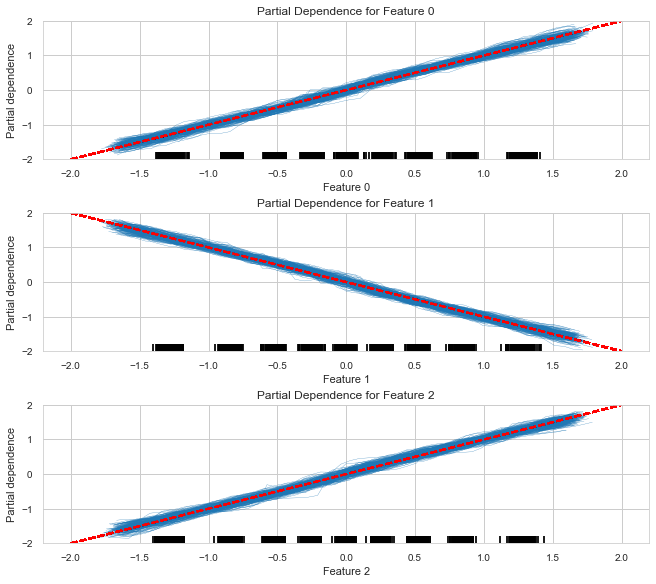

In [98]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from time import time
import seaborn as sns

# Load 30 random forests
#OJO CAMBIA ESTO
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'results')

# Define the range of random forest model files (1 to 30)
num_forests = 250

# List of all random forests (loaded in a loop)
random_forests = []
X_trains = []
y_trains = []

# Theoretical partial dependence functions
def em_1(x):
    return  x

def em_2(x):
    return - x #+3/2

def em_3(x):
    return  x #+1/2

# Loop through the 30 models
for i in range(1, num_forests + 1):
    result_filename = f'euc_samp{i}_N1500_sigma0.6_results.npy'  # Adjust the filename
    result_file_path = os.path.join(results_dir, result_filename)
    
    # Load the results file
    results = np.load(result_file_path, allow_pickle=True).item()
    
    # Extract the Random Forest and data
    random_forests.append(results['forest'])
    X_trains.append(results['x_data'])
    y_trains.append(results['y_data'])

# Define the features of interest (same for all models)
features_info = {
    "features": [0, 1, 2],  # Using the first 5 features
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 50,
    "random_state": 0,
}

# Generate x values for plotting the theoretical functions
x = np.linspace(-2, 2, 100)

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")

# Create a subplot for the PDPs of all models
fig, ax = plt.subplots(ncols=1, nrows=3, figsize=(9, 8), constrained_layout=True)
# Loop through all Random Forests and plot their partial dependence plots
line_kw = {"linewidth": .25}  # Set the desired linewidth here

for j, random_forest in enumerate(random_forests):
    # Generate the Partial Dependence Display for the current Random Forest
    display = PartialDependenceDisplay.from_estimator(
        random_forest, 
        X_trains[j], 
        **features_info, 
        ax=ax, 
        line_kw=line_kw,  # Apply the linewidth setting
        **common_params
    )
    # Plot the theoretical functions on top of the PDP
    for i, feature in enumerate(features_info["features"]):
        # Corresponding theoretical function (em_1, em_2, ..., em_5)
        if i == 0:
            ax[i].plot(x, em_1(x), color='red', linestyle='--')
            ax[i].set_ylim(-2, 2)
        elif i == 1:
            ax[i].plot(x, em_2(x), color='red', linestyle='--')
            ax[i].set_ylim(-2, 2)
        elif i == 2:
            ax[i].plot(x, em_3(x), color='red', linestyle='--')
            ax[i].set_ylim(-2, 2)

        # Adjusting y-limits to fit the theoretical function
        # Calculate the min and max of the theoretical function values to ensure they fit within the frame
        min_theoretical = min([eval(f"em_{i+1}(x)").min() for i in range(3)])
        max_theoretical = max([eval(f"em_{i+1}(x)").max() for i in range(3)])
        #ax[i].set_ylim(min_theoretical * 1.1, max_theoretical * 1.1)  # Add some padding around the theoretical values

        # Set title and label for each subplot
        ax[i].set_title(f'Partial Dependence for Feature {feature}')
        ax[i].set_xlabel(f'Feature {feature}')
        ax[i].set_ylabel('Partial dependence')

In [54]:
X_trains[2].max()

0.9997748600434126

In [ ]:
# Load model results (replace with your own file)
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'results')
result_filename = 'euc_samp2_N200_sigma0.1_results.npy'  # Example filename
result_file_path = os.path.join(results_dir, result_filename)

# Load the results file
results = np.load(result_file_path, allow_pickle=True).item()

# Extract the trained Random Forest model and the data
random_forest = results['forest']
X_train = results['x_data']
y_train = results['y_data']

# Define the features of interest
features_info = {
    "features": [0, 1, 2, 3, 4],  # Using the first 5 features
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 50,
    "random_state": 0,
}


# Generate x values for plotting the theoretical functions
x = np.linspace(0, 1, 100)

# Create the plot
print("Computing partial dependence plots...")
tic = time()

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")
_, ax = plt.subplots(ncols=1, nrows=5, figsize=(9, 8), constrained_layout=True)

# Generate the Partial Dependence Display
display = PartialDependenceDisplay.from_estimator(
    random_forest, 
    X_train, 
    **features_info, 
    ax=ax, 
    **common_params
)

# Plot the theoretical functions on top of the PDP
for i, feature in enumerate(features_info["features"]):
    # Corresponding theoretical function (em_1, em_2, ..., em_5)
    if i == 0:
        ax[i].plot(x, em_1(x), label='$E(m(X)|X_1=x)$', color='red', linestyle='--')
    elif i == 1:
        ax[i].plot(x, em_2(x), label='$E(m(X)|X_2=x)$', color='red', linestyle='--')
    elif i == 2:
        ax[i].plot(x, em_3(x), label='$E(m(X)|X_3=x)$', color='red', linestyle='--')
    elif i == 3:
        ax[i].plot(x, em_4(x), label='$E(m(X)|X_4=x)$', color='red', linestyle='--')
    elif i == 4:
        ax[i].plot(x, em_5(x), label='$E(m(X)|X_5=x)$', color='red', linestyle='--')

    # Adjusting y-limits to fit the theoretical function
    # Calculate the min and max of the theoretical function values to ensure they fit within the frame
    min_theoretical = min([eval(f"em_{i+1}(x)").min() for i in range(5)])
    max_theoretical = max([eval(f"em_{i+1}(x)").max() for i in range(5)])
    ax[i].set_ylim(min_theoretical * 1.1, max_theoretical * 1.1)  # Add some padding around the theoretical values

    # Set title and label for each subplot
    ax[i].set_title(f'Partial Dependence for Feature {feature}')
    ax[i].set_xlabel(f'Feature {feature}')
    ax[i].set_ylabel('Partial dependence')

    # Add a legend
    ax[0].legend()

# Print how long it took to compute
print(f"done in {time() - tic:.3f}s")

# Add a title to the figure
plt.suptitle(
    "Partial dependence plots with Theoretical Functions\n"
    "Simulated data with 5 features",
    fontsize=16
)

# Show the plot
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from time import time
import seaborn as sns

# Load two random forests (change the filenames as needed)
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'results')

# Example filenames for two different models
result_filename_1 = 'euc_samp1_N50_sigma0.1_results.npy'  # First random forest
result_filename_2 = 'euc_samp2_N50_sigma0.1_results.npy'  # Second random forest

# Load the results for the first and second random forests
result_file_path_1 = os.path.join(results_dir, result_filename_1)
result_file_path_2 = os.path.join(results_dir, result_filename_2)

# Load the results files
results_1 = np.load(result_file_path_1, allow_pickle=True).item()
results_2 = np.load(result_file_path_2, allow_pickle=True).item()

# Extract the trained Random Forest models and the data
random_forest_1 = results_1['forest']
random_forest_2 = results_2['forest']
X_train_1 = results_1['x_data']
y_train_1 = results_1['y_data']

X_train_2 = results_2['x_data']
y_train_2 = results_2['y_data']

# Define the features of interest (same for both models)
features_info = {
    "features": [0, 1, 2, 3, 4],  # Using the first 5 features
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 50,
    "random_state": 0,
}

# Generate x values for plotting the theoretical functions
x = np.linspace(0, 1, 100)

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")

# Create a subplot for the PDPs of both models
fig, ax = plt.subplots(ncols=1, nrows=5, figsize=(9, 8), constrained_layout=True)

# Generate the Partial Dependence Display for the first Random Forest
display_1 = PartialDependenceDisplay.from_estimator(
    random_forest_1, 
    X_train_1, 
    **features_info, 
    ax=ax, 
    **common_params
)

# Generate the Partial Dependence Display for the second Random Forest
display_2 = PartialDependenceDisplay.from_estimator(
    random_forest_2, 
    X_train_2, 
    **features_info, 
    ax=ax, 
    **common_params
)

# Show the plot
plt.suptitle(
    "Partial Dependence Plots for Two Random Forests\n"
    "Simulated data with 5 features",
    fontsize=16
)

plt.show()


ValueError: Expected ax to have 4 axes, got 5

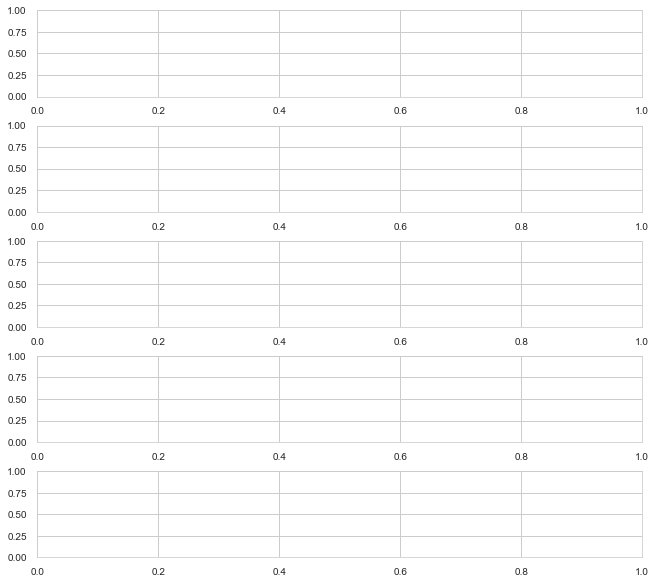

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from time import time
import seaborn as sns

# Load 30 random forests
#OJO CAMBIA ESTO
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'results')

# Define the range of random forest model files (1 to 30)
num_forests = 50

# List of all random forests (loaded in a loop)
random_forests = []
X_trains = []
y_trains = []

# Theoretical partial dependence functions
def em_1(x):
    return -2 - 2*x + 4/np.pi + 11/12

def em_2(x):
    return -7/3 + 2*np.sin(np.pi*x) + 1/2*x

def em_3(x):
    return 4/np.pi - 7/4 - x**2

# def em_4(x):
#     return 4/np.pi - 7/3 + x/2

def em_4(x):
    return 4/np.pi - 37/12 + 2*x
    
# Loop through the 30 models
for i in range(1, num_forests + 1):
    result_filename = f'euc_samp{i}_N500_sigma0.1_results.npy'  # Adjust the filename
    result_file_path = os.path.join(results_dir, result_filename)
    
    # Load the results file
    results = np.load(result_file_path, allow_pickle=True).item()
    
    # Extract the Random Forest and data
    random_forests.append(results['forest'])
    X_trains.append(results['x_data'])
    y_trains.append(results['y_data'])

# Define the features of interest (same for all models)
features_info = {
    "features": [0, 1, 2, 3],  # Using the first 5 features
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 50,
    "random_state": 0,
}

# Generate x values for plotting the theoretical functions
x = np.linspace(0, 1, 100)

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")

# Create a subplot for the PDPs of all models
fig, ax = plt.subplots(ncols=1, nrows=5, figsize=(9, 8), constrained_layout=True)
# Loop through all Random Forests and plot their partial dependence plots
line_kw = {"linewidth": .25}  # Set the desired linewidth here

for j, random_forest in enumerate(random_forests):
    # Generate the Partial Dependence Display for the current Random Forest
    display = PartialDependenceDisplay.from_estimator(
        random_forest, 
        X_trains[j], 
        **features_info, 
        ax=ax, 
        line_kw=line_kw,  # Apply the linewidth setting
        **common_params
    )
    # Plot the theoretical functions on top of the PDP
    for i, feature in enumerate(features_info["features"]):
        # Corresponding theoretical function (em_1, em_2, ..., em_5)
        if i == 0:
            ax[i].plot(x, em_1(x), color='red', linestyle='--')
        elif i == 1:
            ax[i].plot(x, em_2(x), color='red', linestyle='--')
        elif i == 2:
            ax[i].plot(x, em_3(x), color='red', linestyle='--')
        elif i == 3:
            ax[i].plot(x, em_4(x), color='red', linestyle='--')
#        elif i == 4:
#            ax[i].plot(x, em_5(x), color='red', linestyle='--')

        # Adjusting y-limits to fit the theoretical function
        # Calculate the min and max of the theoretical function values to ensure they fit within the frame
        min_theoretical = min([eval(f"em_{i+1}(x)").min() for i in range(4)])
        max_theoretical = max([eval(f"em_{i+1}(x)").max() for i in range(4)])
        ax[i].set_ylim(min_theoretical * 1.1, max_theoretical * 1.1)  # Add some padding around the theoretical values

        # Set title and label for each subplot
        ax[i].set_title(f'Partial Dependence for Feature {feature}')
        ax[i].set_xlabel(f'Feature {feature}')
        ax[i].set_ylabel('Partial dependence')

/Users/Diego/miniconda3/envs/pballs/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


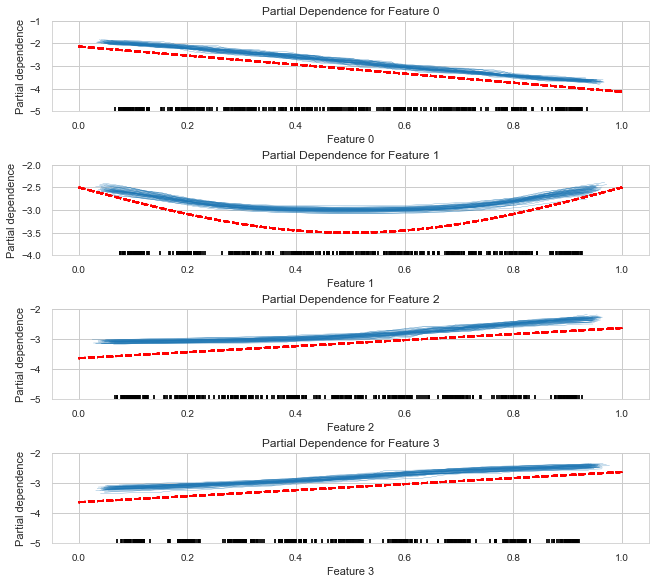

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
# Theoretical partial dependence functions
def em_1(x):
    return -2 - 2*x - 2/np.pi + 1/2

def em_2(x):
    return - 3 + 1/2 - np.sin(np.pi*x)

def em_3(x):
    return - 3 - 2/np.pi + x

# Load 30 random forests
#OJO CAMBIA ESTO
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'results')

# Define the range of random forest model files (1 to 30)
num_forests = 50

# List of all random forests (loaded in a loop)
random_forests = []
X_trains = []
y_trains = []

# Loop through the 30 models
for i in range(1, num_forests + 1):
    result_filename = f'euc_samp{i}_N500_sigma0.1_results.npy'  # Adjust the filename
    result_file_path = os.path.join(results_dir, result_filename)
    
    # Load the results file
    results = np.load(result_file_path, allow_pickle=True).item()
    
    # Extract the Random Forest and data
    random_forests.append(results['forest'])
    X_trains.append(results['x_data'])
    y_trains.append(results['y_data'])

# Define the features of interest (same for all models)
features_info = {
    "features": [0, 1, 2, 3],  # Using the first 4 features
    "kind": "average",  # Type of partial dependence plot (average over other features)
}

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 50,
    "random_state": 0,
}

# Generate x values for plotting the theoretical functions
x = np.linspace(0, 1, 100)

# Set custom matplotlib style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-notebook")

# Create a subplot for the PDPs of all models
fig, ax = plt.subplots(ncols=1, nrows=4, figsize=(9, 8), constrained_layout=True)
# Loop through all Random Forests and plot their partial dependence plots
line_kw = {"linewidth": .25}  # Set the desired linewidth here

for j, random_forest in enumerate(random_forests):
    # Generate the Partial Dependence Display for the current Random Forest
    display = PartialDependenceDisplay.from_estimator(
        random_forest, 
        X_trains[j], 
        **features_info, 
        ax=ax, 
        line_kw=line_kw,  # Apply the linewidth setting
        **common_params
    )
    # Plot the theoretical functions on top of the PDP
    for i, feature in enumerate(features_info["features"]):
        # Corresponding theoretical function (em_1, em_2, ..., em_5)
        if i == 0:
            ax[i].plot(x, em_1(x), color='red', linestyle='--')
            ax[i].set_ylim(-5,-1)
        elif i == 1:
            ax[i].plot(x, em_2(x), color='red', linestyle='--')
            ax[i].set_ylim(-4,-2)
        elif i == 2:
            ax[i].plot(x, em_3(x), color='red', linestyle='--')
            ax[i].set_ylim(-5,-2)
        elif i == 3:
            ax[i].plot(x, em_3(x), color='red', linestyle='--')
            ax[i].set_ylim(-5,-2)

        # Adjusting y-limits to fit the theoretical function
        # Calculate the min and max of the theoretical function values to ensure they fit within the frame
        # min_theoretical = min([eval(f"em_{i+1}(x)").min() for i in range(3)])
        # max_theoretical = max([eval(f"em_{i+1}(x)").max() for i in range(3)])
        # ax[i].set_ylim(min_theoretical * 1.1, max_theoretical * 1.1)  # Add some padding around the theoretical values

        # Set title and label for each subplot
        ax[i].set_title(f'Partial Dependence for Feature {feature}')
        ax[i].set_xlabel(f'Feature {feature}')
        ax[i].set_ylabel('Partial dependence')


In [ ]:
betas

array([-2, -2, -1,  1,  2])

In [ ]:
for p in np.linspace(0, 1, 50, endpoint=False):
    print(np.round(p, 2), np.abs(random_forest.predict(np.repeat(p, 5).reshape(1, 5)) - simulate_data(sigma = 0.1, X_design = np.repeat(p, 1000*5).reshape(1000, 5), betas = betas)[1].mean()))

In [ ]:
errors = []

for _ in range(300):
    p = np.random.uniform()
    p_errors = []
    y_pred = random_forest.predict(np.repeat(p, 1000*5).reshape(1000, 5))
    y_true = simulate_data(sigma=0.1, X_design=np.repeat(p, 1000*5).reshape(1000, 5), betas=betas)[1]
    error = np.abs(y_pred - y_true)
    p_errors.append(error)
    mean_error = np.mean(p_errors)
    std_error = np.std(p_errors)
    errors.append((p, mean_error, std_error))
    if mean_error > 0.6:
        print(f"p: {p}, Mean Error: {mean_error}, Std Error: {std_error}, y_true: {y_true}, y_pred: {y_pred}")

In [ ]:
errors = []

for p in np.linspace(0, 1, 50, endpoint=False):
    p_errors = []
    y_pred = random_forest.predict(np.repeat(p, 10000*5).reshape(10000, 5))
    y_true = simulate_data(sigma=0.1, X_design=np.repeat(p, 10000*5).reshape(10000, 5), betas=betas)[1]
    error = np.abs(y_pred - y_true)
    p_errors.append(error)
    mean_error = np.mean(p_errors)
    std_error = np.std(p_errors)
    errors.append((np.round(p, 2), mean_error, std_error))

for p, mean_error, std_error in errors:
    print(f"p: {p}, Mean Error: {mean_error}, Std Error: {std_error}")

In [ ]:
quant = np.percentile(np.abs(random_forest.oob_prediction_ - y_train), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')
X = np.repeat([0.2, 0.5,0.1,0.8,0.7], 10000).reshape(10000, 5)
y = simulate_data(sigma = 0.1, X_design = X, betas = betas)[1].reshape(-1,1)
pred = random_forest.predict(X).reshape(-1,1)
np.sum(np.abs(pred - y) <= quant, axis = 0)/10000